In [1]:
setwd("~/GSE247684_A375")

In [52]:
library(Seurat)
library(gridExtra)
library(ComplexHeatmap)
library(RColorBrewer)
library(data.table)
library(clustree)
library(dplyr)
library(fastCNV)

## Step1

### Create a Seurat object and export the expression data.

In [ ]:
expr_mat <- fread("./data_path/a375_all_C_to_T4.csv")
expr_mat <- as.data.frame(expr_mat)
rownames(expr_mat) <- expr_mat[,1]
expr_mat <- expr_mat[,-1]
expr_mat <- as.matrix(expr_mat)

In [13]:
meta <- fread("./data_path/GSE247684_a375_metadata_g1.tsv")
meta <- as.data.frame(meta)
rownames(meta) <- meta[,1]
common_cells <- intersect(colnames(expr_mat), rownames(meta))
expr_mat <- expr_mat[, common_cells]
meta <- meta[common_cells, ]

In [14]:
seu <- CreateSeuratObject(
  counts = expr_mat,
  project = "A375",
  meta.data = meta
)

Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”


In [ ]:
seu <- NormalizeData(seu, normalization.method = "LogNormalize", scale.factor = 10000)
seu <- FindVariableFeatures(seu, selection.method = "vst", nfeatures = 2000)
seu <- ScaleData(seu, vars.to.regress = c("nCount_RNA"))
seu <- RunPCA(seu, features = VariableFeatures(object = seu), reduction.name = "pca")
seu <- FindNeighbors(seu, reduction = "pca", dims = 1:10)
seu <- FindClusters(seu, resolution = seq(0.1, 1, by = 0.1), algorithm = 1)
#seu <- FindClusters(seu, resolution = 0.4, algorithm = 1)
seu <- RunUMAP(seu, reduction = "pca", dims = 1:10, reduction.name = "umap")

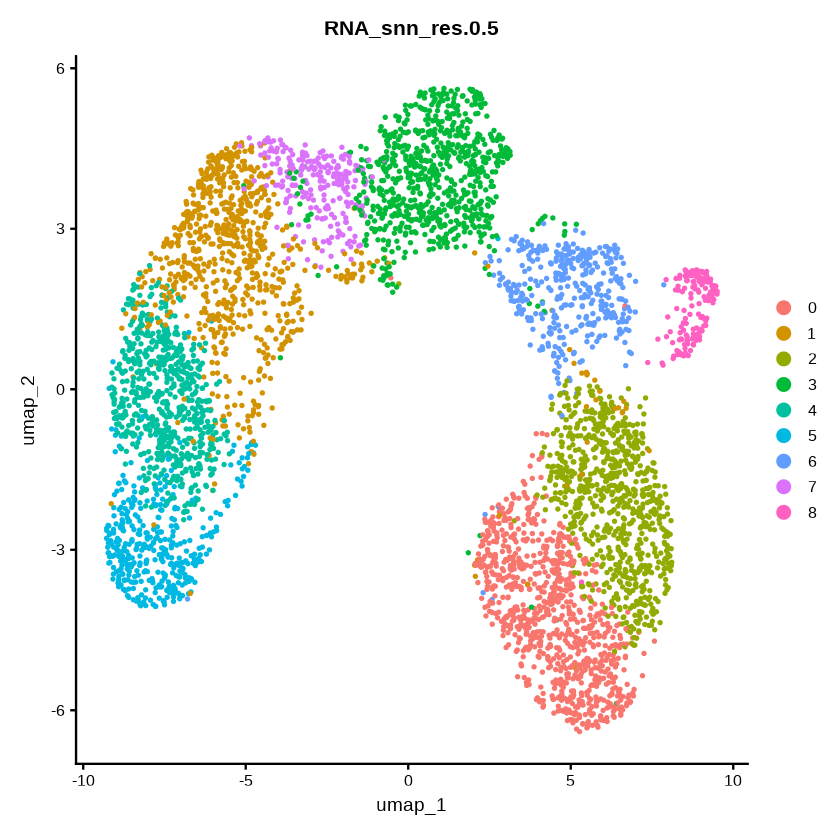

In [21]:
p = DimPlot(seu,group.by = "RNA_snn_res.0.5")
p

In [5]:
expr <- GetAssayData(seu, assay = "RNA", layer = "data")  # log-normalized

In [ ]:
orig <- AggregateExpression(
  seu,
  assays = "RNA",
  group.by = "orig.ident",
  normalization.method = "LogNormalize",
  scale.factor = 10000,
  return.seurat = TRUE
)
expr_orig <- GetAssayData(orig, assay = "RNA", layer = "data")
write.csv(as.data.frame(expr_orig), "GSE247684_A375_exp_orig.csv", quote = FALSE)

In [14]:
expr_sc <- GetAssayData(seu, assay = "RNA", layer = "data")  
write.csv(as.data.frame(expr_sc), "GSE247684_A375_exp_sc.csv", quote = FALSE)

## Step2

### Import the prediction scores for each spot generated by DEPICT.

## DEPICT

In [40]:
DEPICT = read.csv("GSE247684_A375_DEPICT_result.csv", header = T)

In [ ]:
# For the same sample, the available `Score_norm` values have already been normalized and therefore do not need to be normalized again. 
# If some cells need to be excluded, first remove those cells based on their scores and then perform normalization on the remaining cells.

In [41]:
DEPICT = DEPICT[DEPICT$Drug_name %in% "Dabrafenib",]
rownames(DEPICT) = DEPICT$Samples_id
DEPICT = DEPICT[, c("Score_norm"), drop = FALSE]
colnames(DEPICT) = c("DEPICT_Dabrafenib_result")
seu <- AddMetaData(seu, DEPICT)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Saving 6.67 x 6.67 in image


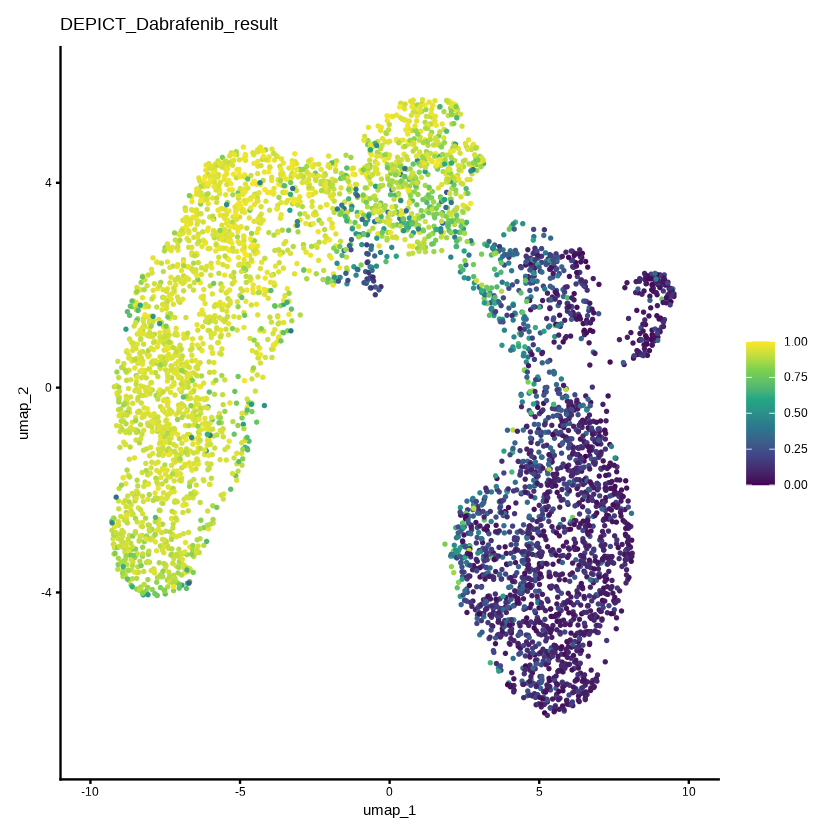

In [42]:
p = FeaturePlot(seu, 
                features = "DEPICT_Dabrafenib_result") +
    scale_color_viridis_c() +
    theme_classic()
p
ggsave(p, file = "DEPICT_Dabrafenib_result.pdf")

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Saving 6.67 x 6.67 in image


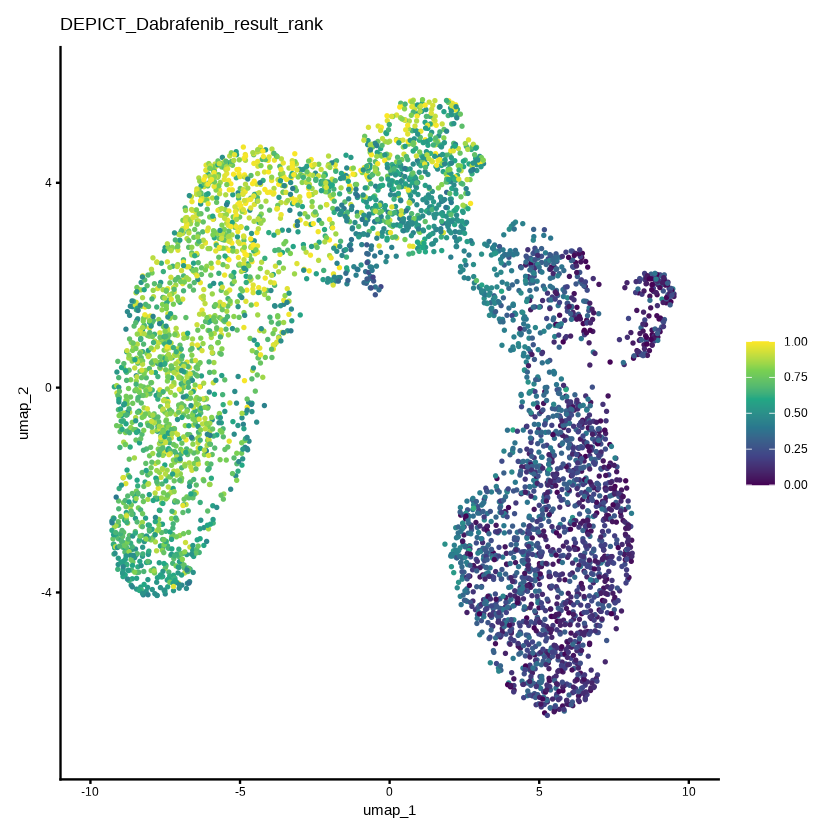

In [43]:
seu$DEPICT_Dabrafenib_result_rank <- percent_rank(seu[["DEPICT_Dabrafenib_result"]])
p <- FeaturePlot(
    seu,
    features = "DEPICT_Dabrafenib_result_rank"
  ) +
    scale_color_viridis_c() +
    theme_classic()
p
ggsave(p, file = "DEPICT_Dabrafenib_result_rank.pdf")

Picking joint bandwidth of 0.036

Saving 6.67 x 6.67 in image
Picking joint bandwidth of 0.036



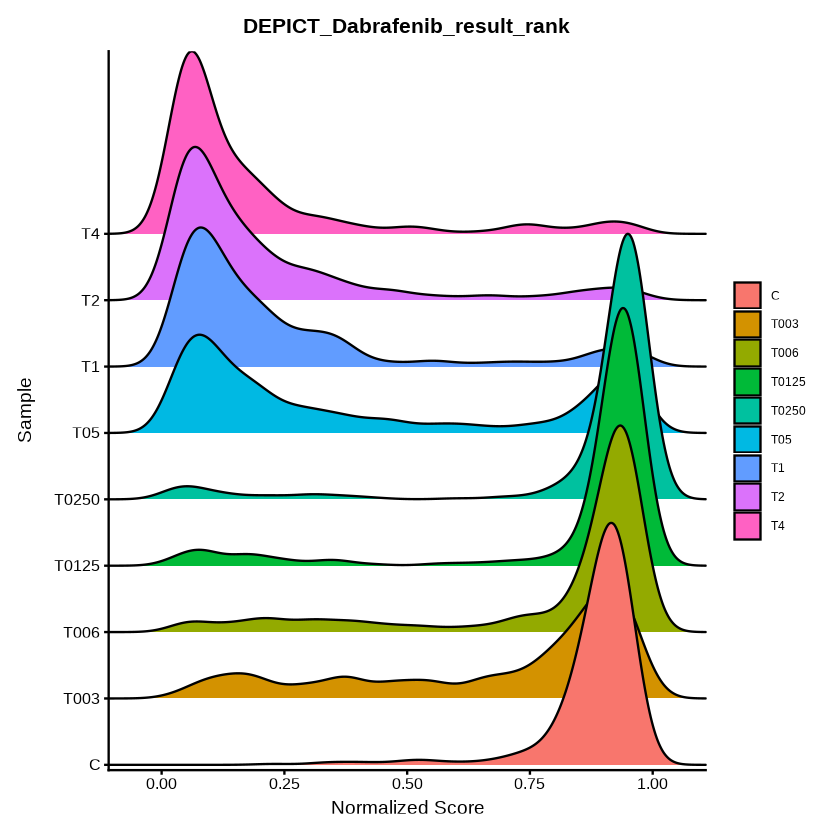

In [50]:
p <- RidgePlot(
    seu,
    features = "DEPICT_Dabrafenib_result",
    group.by = "orig.ident"
    ) +
    theme_classic() +
    labs(
      title = "DEPICT_Dabrafenib_result_rank",
      x = "Normalized Score",
      y = "Sample"
    ) +
    theme(
      axis.text = element_text(size = 12, color = "black"),
      axis.title = element_text(size = 14),
      plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
      legend.position = "right"
)
p
ggsave(p, file = "DEPICT_Dabrafenib_RidgePlot.pdf")

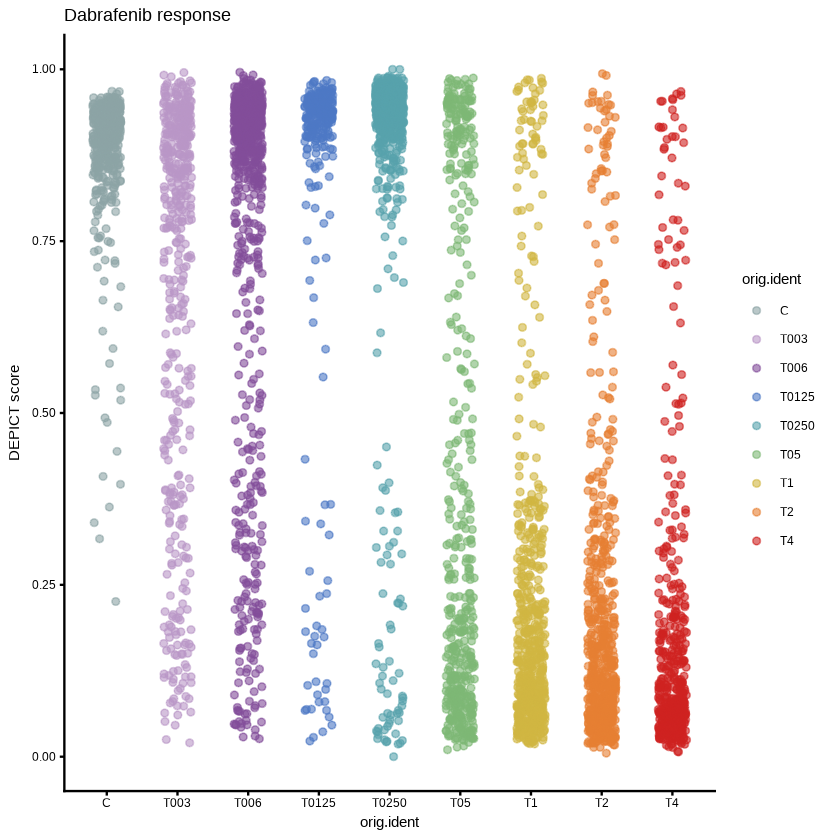

In [51]:
colors = c("#8DA3A6", "#B997C7","#824D99","#4E78C4",
           "#57A2AC","#7EB875","#D0B541",
           "#E67F33", "#CE2220")

df <- FetchData(seu, vars = c(
  "DEPICT_Dabrafenib_result", 
  "orig.ident"
))

p = ggplot(df, aes(x = orig.ident, 
                   y = DEPICT_Dabrafenib_result,
                   olor = orig.ident)) +
  geom_jitter(width = 0.2, size = 1.5, alpha = 0.6) +
  scale_color_manual(values = colors) +
  labs(
    x = "orig.ident",
    y = "DEPICT score",
    title = "Dabrafenib response"
  ) +
  theme_classic()
p
ggsave("DEPICT_Dabrafenib_scatter.pdf",plot = p,width = 8,height = 5)

[2026-05-28 16:02:55] Aggregating counts matrix...

[2026-05-28 16:03:07] Done !

[2026-05-28 16:03:07] Running CNV analysis...

Using genes data from ensembl version 113.

[2026-05-28 16:03:29] Done !

[2026-05-28 16:03:30] Computing CNV per chromosome arm...

[2026-05-28 16:03:31] Done !

[2026-05-28 16:03:31] Clustering CNVs...

[2026-05-28 16:03:54] Done !

[2026-05-28 16:03:54] Plotting CNV heatmap...

CNV plot for sample object saved at ./heatmap.fastCNV_object.pdf

[2026-05-28 16:05:27] Done !



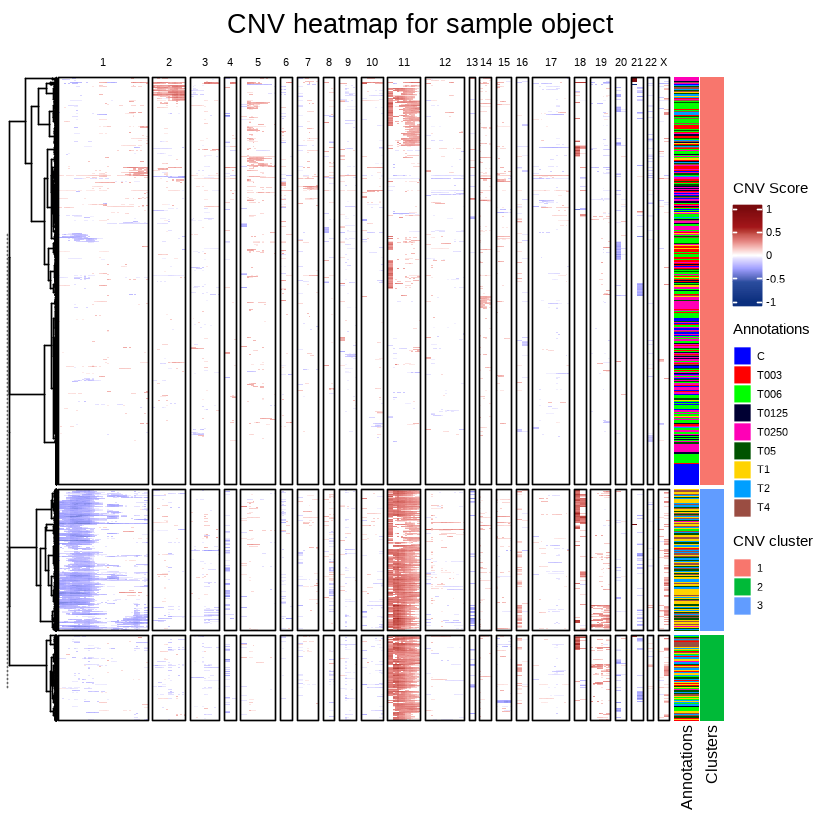

In [8]:
object <- fastCNV(seu, 
                  sampleName = "object",
                  referenceVar = "orig.ident",
                  referenceLabel = c("C"), 
                  outputType = "pdf",
                  printPlot = T
                 )